In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Global Variables
FILE_PATH: str = "https://raw.githubusercontent.com/vinayak-ensemble/Dataset-TV-Shows-OTT/refs/heads/main/tv-shows.csv" 
OTT_DF: pd.DataFrame = pd.read_csv(FILE_PATH)

In [5]:
OTT_DF.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix


In [6]:
OTT_DF[['title', 'director', 'cast', 'description']].head()

,title,director,cast,description
0,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,From colors and letters to animals of all kind...
1,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",Spirited 22-year-old activist and photojournal...
2,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...","Years after getting his girlfriend pregnant, w..."
3,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",On returning home and finding they're believed...
4,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...","Hoping to find a magical root, a monster has c..."


In [7]:
# Check for columns and null values present in the dataframe

OTT_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 9338 entries, 0 to 9337
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            9338 non-null   int64
 1   type          9338 non-null   str  
 2   title         9338 non-null   str  
 3   director      6483 non-null   str  
 4   cast          8400 non-null   str  
 5   country       8376 non-null   str  
 6   date_added    9325 non-null   str  
 7   release_year  9338 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9335 non-null   str  
 10  listed_in     9338 non-null   str  
 11  description   9338 non-null   str  
 12  platform      9338 non-null   str  
dtypes: int64(2), str(11)
memory usage: 948.5 KB


In [8]:
# Converting the date_added to datetime format:
OTT_DF['date_added'] = pd.to_datetime(OTT_DF['date_added'].str.strip(), format='%B %d, %Y')

In [9]:
# Check the distribution
OTT_DF['date_added'].describe()

# Conclusion: 
# - The distribution is positively skewed, having been added recently

count                          9325
mean     2019-07-13 00:59:17.919571
min             2008-01-01 00:00:00
25%             2018-08-01 00:00:00
50%             2019-11-12 00:00:00
75%             2020-09-02 00:00:00
max             2021-11-26 00:00:00
Name: date_added, dtype: object

In [10]:
OTT_DF['release_year'].describe()
# Conclusion: 
# - The distribution is positively skewed, having movies from recent years.
# - The distribution is more skewed than the `date_added`, 
#   which means that old movies have been added relatively recently.

count    9338.000000
mean     2012.462305
std        12.512379
min      1928.000000
25%      2012.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [11]:
# Count the null values in each column and the respective % for the same

pd.DataFrame(OTT_DF.isnull().sum(), columns=['count']).join(
    pd.DataFrame((OTT_DF.isnull().sum() / OTT_DF.shape[0] * 100).apply(lambda x: str(round(x, 2)) + " %"), columns=['percentage']),
    how='left'
)

# Conclusion: 
# - director, cast and country have > 10% missing value, since they are string columns we can fill in Unknown for them.
# - date_added, release_year, rating and duration have <1% so we can treat them them with mean (numeric columns) 
#   and mode (string columns), this will ensure that the overall distribution doesn't change. 


,count,percentage
id,0,0.0 %
type,0,0.0 %
title,0,0.0 %
director,2855,30.57 %
cast,938,10.04 %
country,962,10.3 %
date_added,13,0.14 %
release_year,0,0.0 %
rating,7,0.07 %
duration,3,0.03 %


In [13]:
# Analysing the combined value columns are other important columns

def check_unique(df: pd.DataFrame, col: str, label: str = None):
    if label is None:
        label = col
    print(f"Unique {label} Combinations: ", df[col].dropna().nunique())
    print(f"Unique {label} :", len(list(filter(lambda x: x != '', set(', '.join(df[col].dropna().unique()).split(', '))))))

check_for_cols = ['director', 'cast', 'country', 'listed_in', 'platform']
for col in check_for_cols:
    check_unique(OTT_DF, col)
    print('_'*50, end='\n\n')

# Conclusion:
# - director: There are some movies that have more than 1 director.
# - cast: The unique count is roughly 4x compared to it's combination.
# - country: The data covers most of the countries (121 / 195).
# - listed_in: The combination values is roughly 10x compared to it's unique count.
# - platform: Platform doesn't have any combinations, there is only a single value for each
#   - The rating and description might vary in the 2 platforms [there may be duplicates] 

Unique director Combinations:  4630
Unique director : 5059
__________________________________________________

Unique cast Combinations:  8079
Unique cast : 35957
__________________________________________________

Unique country Combinations:  733
Unique country : 121
__________________________________________________

Unique listed_in Combinations:  825
Unique listed_in : 84
__________________________________________________

Unique platform Combinations:  2
Unique platform : 2
__________________________________________________



In [14]:
# Check the unit for this column
set(map(lambda x: str(x).split(' ')[1], OTT_DF['duration'].dropna().unique()))

# Conclusion: 
# - Need to decompose this into 2 columns Series and Movie
# - Final output would be duration_mins and duration_Seasons [combine type and duration to form 2 meaningful columns]

{'Season', 'Seasons', 'min'}

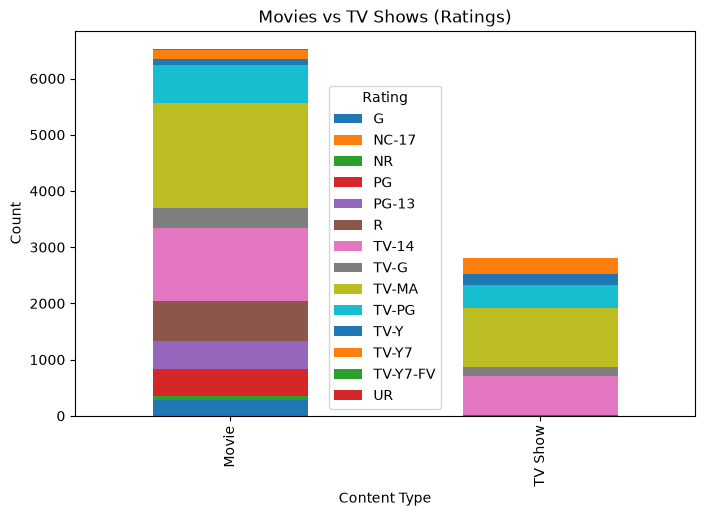

In [53]:
# Check the Distribution of Ratings across Movies and TV Shows 
content_platform = pd.crosstab(OTT_DF.dropna(subset='duration')['type'], OTT_DF.dropna(subset='duration')['rating'])
content_platform.plot(kind='bar',stacked=True,figsize=(8,5))

plt.title("Movies vs TV Shows (Ratings)")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.legend(title="Rating")
plt.show()

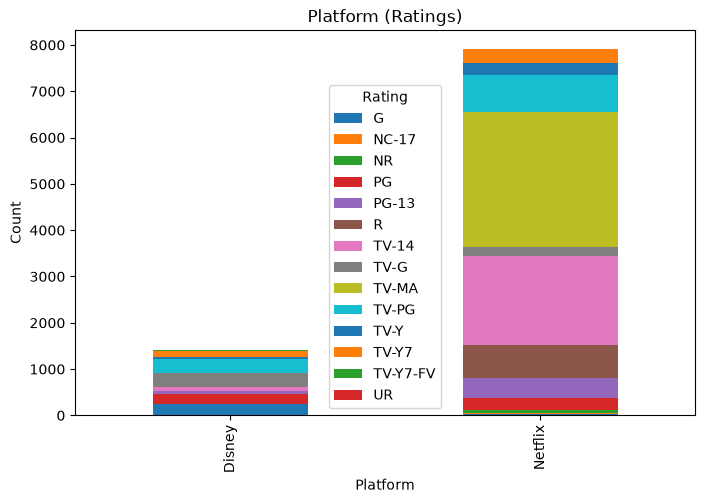

In [52]:
# Check the Distribution of Ratings across Platforms
content_platform = pd.crosstab(OTT_DF.dropna(subset='duration')['platform'], OTT_DF.dropna(subset='duration')['rating'])
content_platform.plot(kind='bar',stacked=True,figsize=(8,5))

plt.title("Platform (Ratings)")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.legend(title="Rating")
plt.show()

In [12]:
# The duration for the values gave gone into the ratings column
# - need to move them into duration and make rating as Nan

OTT_DF[OTT_DF['duration'].isna()][['duration','rating']]

,duration,rating
3917,NaN,66 min
5570,NaN,84 min
6660,NaN,74 min


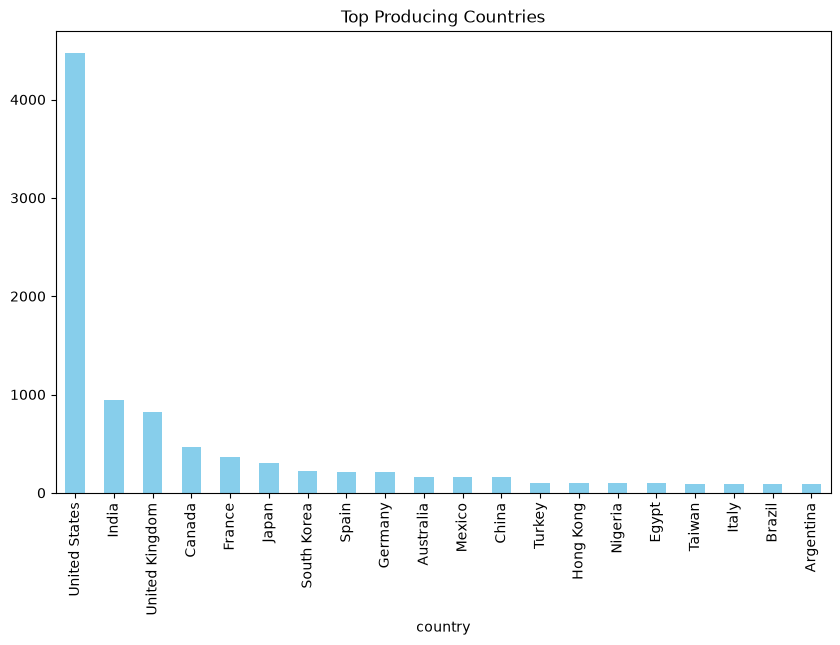

In [ ]:
# Check for Top Producing Countries 
countries = (OTT_DF['country'].dropna().str.split(',').explode().str.strip())
plt.figure(figsize=(10,6))
countries.value_counts().head(20).plot(kind='bar', color='skyblue')
plt.title("Top Producing Countries")
plt.show()

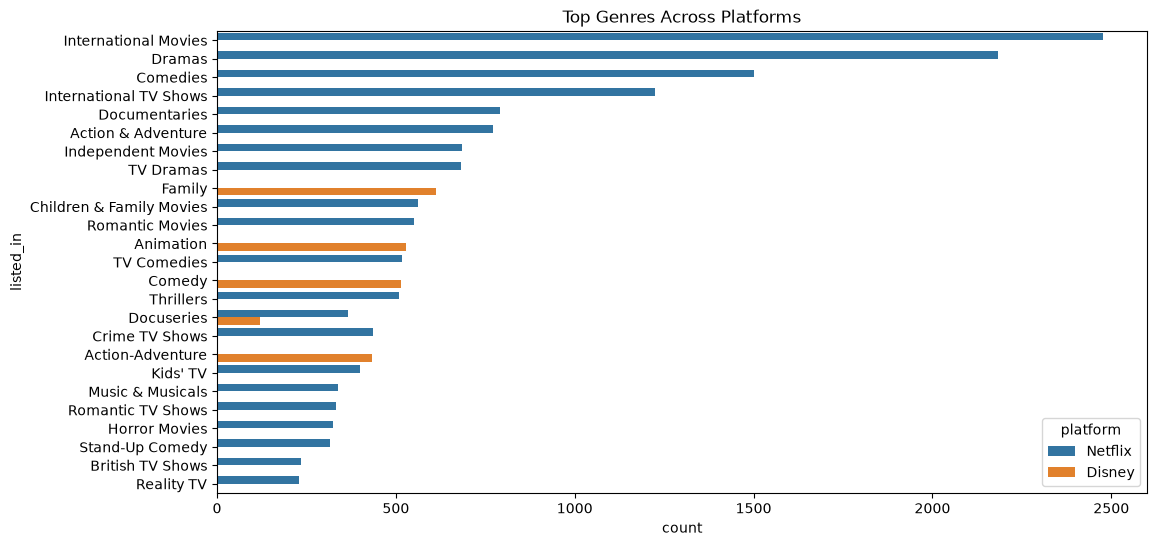

In [ ]:
# Check for top 25 generes that listed accross both platforms

genre_df = OTT_DF.copy()
top_genres = genre_df['listed_in'].value_counts().head(25).index

genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
top_genres = genre_df['listed_in'].value_counts().head(25).index

plt.figure(figsize=(12,6))
sns.countplot(data=genre_df[genre_df['listed_in'].isin(top_genres)],
              y='listed_in',
              hue='platform', 
              order=top_genres)
plt.title("Top Genres Across Platforms")
plt.show()

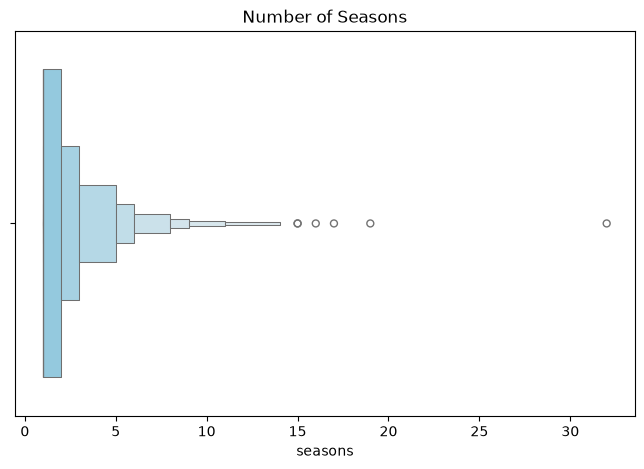

In [ ]:
# Check for the distribution of number of seassons for TV Shows

shows = OTT_DF[OTT_DF['type']=='TV Show'].copy()

shows['seasons'] = shows['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(8,5))
sns.boxenplot(data=shows, x='seasons', color='skyblue')
plt.title("Number of Seasons")
plt.show()

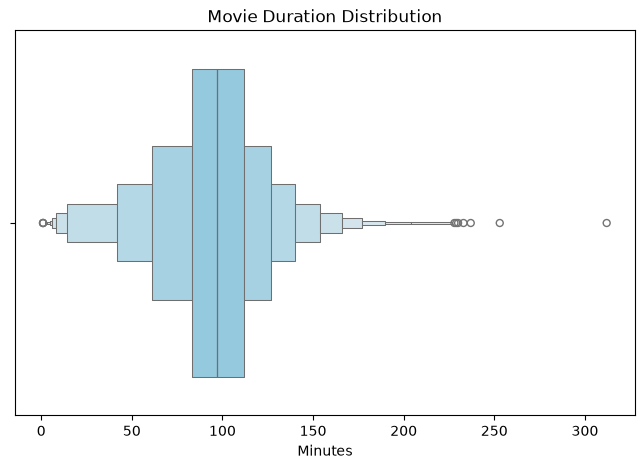

In [ ]:
# Check for the duration distribution of Movies

movies = OTT_DF[OTT_DF['type']=='Movie'].copy()

movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(8,5))
sns.boxenplot(x=movies['duration_min'], color='skyblue')
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.show()

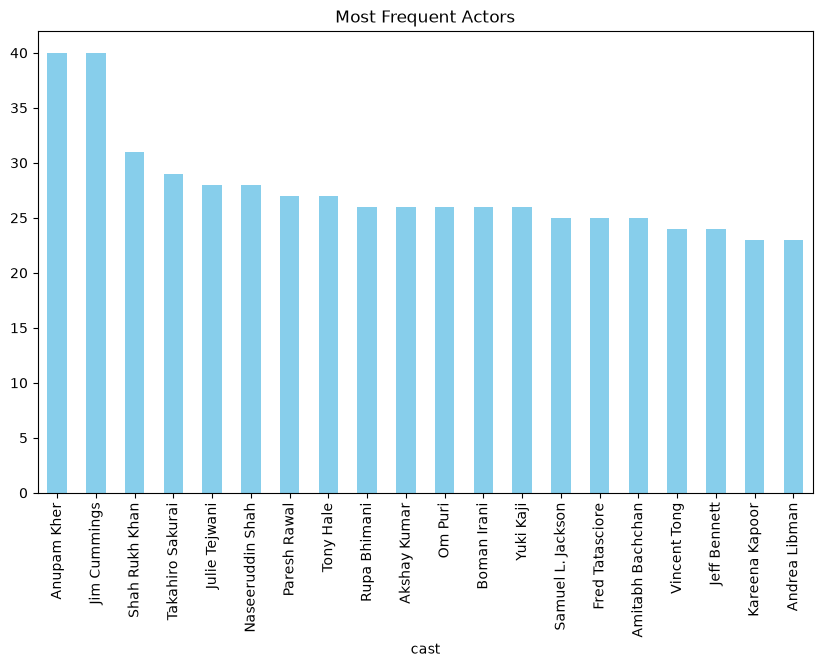

In [ ]:
# Top actors
actors = (OTT_DF['cast'].dropna().str.split(',').explode().str.strip())

plt.figure(figsize=(10,6))
actors.value_counts().head(20).plot(kind='bar', color='skyblue')
plt.title("Most Frequent Actors")
plt.show()

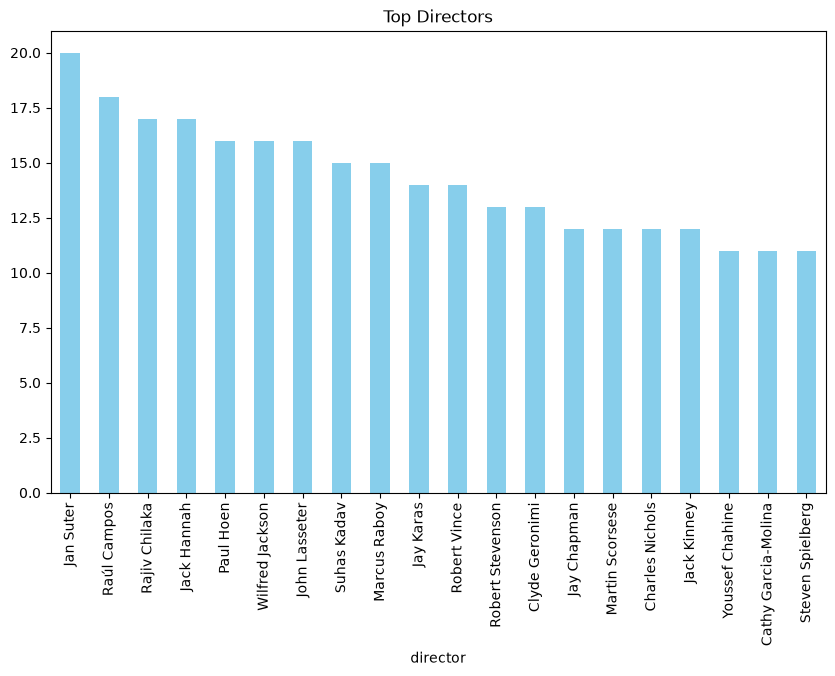

In [ ]:
# Top Directors
directors = (OTT_DF['director'].dropna().str.split(',').explode().str.strip())

plt.figure(figsize=(10,6))
directors.value_counts().head(20).plot(kind='bar', color='skyblue')
plt.title("Top Directors")
plt.show()

_____